# Transaction Processing Analysis

This notebook analyses the propagation and processing of transactions throughout a single simulation run.

## 1. Load Libraries and Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Enable copy-on-write to follow pandas recommendation.
# see https://pandas.pydata.org/docs/user_guide/copy_on_write.html
pd.options.mode.copy_on_write = True

In [7]:
# Replace '../output.csv' with the path to your CSV file
# As a reminder, please run `go run ./daphne run` to produce this file
data = pd.read_csv('../output.csv')

# Filter rows with relevant 'mark' values
data = data[data['mark'].str.startswith('Tx')]

## 2. Transaction Processing Rate
The following chart illustrates the transaction processing rate per second over the duration of the evaluation.

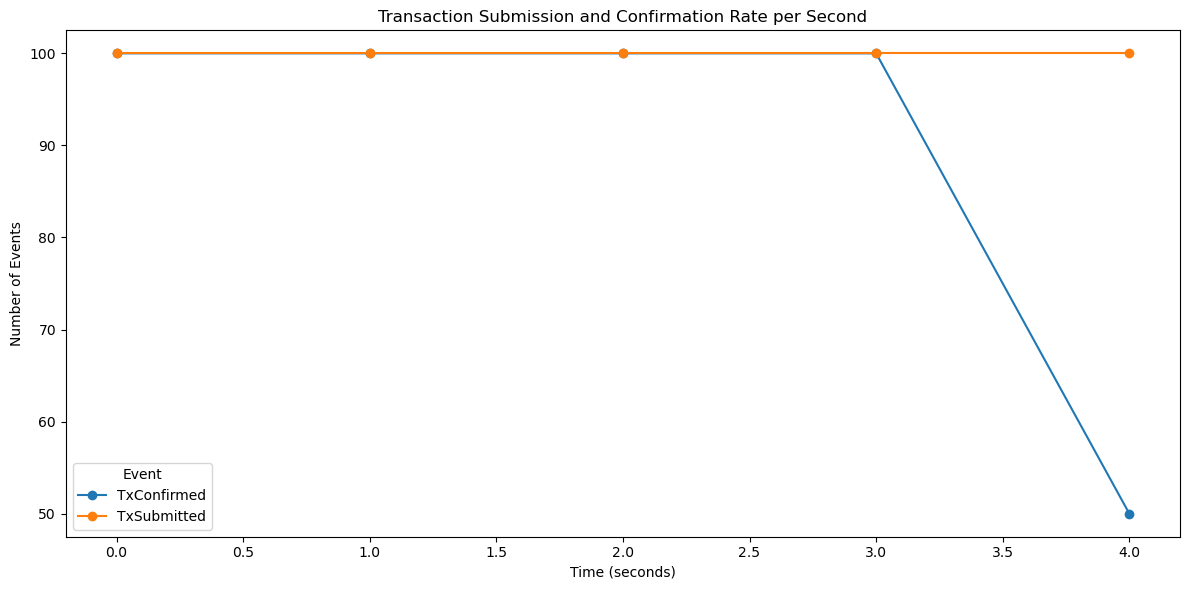

In [8]:
# Convert timestamp to seconds (assuming timestamp is in nanoseconds)
data['time_sec'] = (data['timestamp'] - data['timestamp'].min()) / 1e9

# Filter for TxSubmitted and TxConfirmed events
submitted_confirmed = data[data['mark'].isin(['TxSubmitted', 'TxConfirmed'])]

# For each hash and mark, keep only the earliest event
unique_events = submitted_confirmed.sort_values('timestamp').groupby(['hash', 'mark'], as_index=False).first()

# Bin by second
unique_events['second'] = unique_events['time_sec'].astype(int)

# Count per second for each event type
rate_per_second = unique_events.groupby(['second', 'mark']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
rate_per_second.plot(ax=plt.gca(), marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Events')
plt.title('Transaction Submission and Confirmation Rate per Second')
plt.legend(title='Event')
plt.tight_layout()
plt.show()

## 3. Transaction Latency

The following chart plots the distribution of the Time To Finality (TTF) of all transactions processed during the simulation. For this, the TTF of a transaction T is defined as the time delay between the first RPC receiving the transaction and the first moment the transaction's receipt was ready on any node.

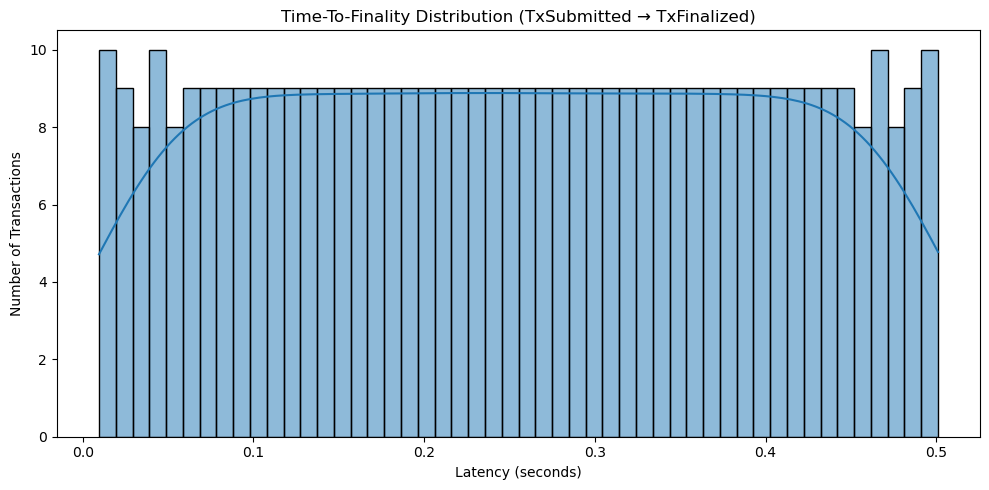

In [9]:
# Find first TxSubmitted and TxFinalized timestamps per transaction (in nanoseconds)
submitted = data[data['mark'] == 'TxSubmitted'].sort_values('timestamp').groupby('hash', as_index=False).first()
finalized = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).first()

# Merge to get both timestamps per transaction
latency_df = pd.merge(
    submitted[['hash', 'timestamp']],
    finalized[['hash', 'timestamp']],
    on='hash',
    suffixes=('_submitted', '_finalized')
)

# Compute latency in seconds from nanoseconds
latency_df['latency'] = (latency_df['timestamp_finalized'] - latency_df['timestamp_submitted']) / 1e9

# Plot latency distribution
plt.figure(figsize=(10, 5))
sns.histplot(latency_df['latency'], bins=50, kde=True)
plt.xlabel('Latency (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Time-To-Finality Distribution (TxSubmitted → TxFinalized)')
plt.tight_layout()
plt.show()

The following chart shows the latency distribution between the first and last node in the network reaching the finalization point of a transaction.

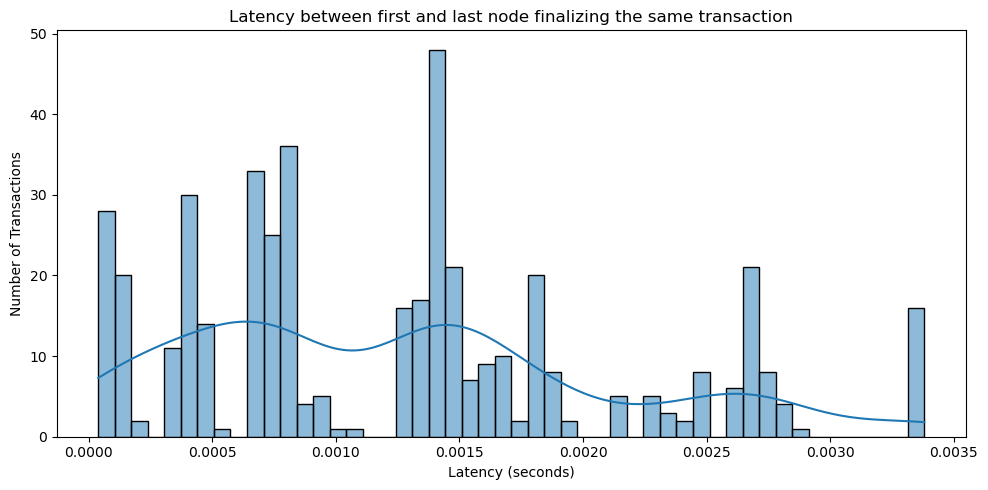

In [10]:
# Find first and last TxFinalized timestamps per transaction (in nanoseconds)
earliest = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).first()
latest = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).last()

# Merge to get both timestamps per transaction
latency_df = pd.merge(
    earliest[['hash', 'timestamp']],
    latest[['hash', 'timestamp']],
    on='hash',
    suffixes=('_earliest', '_latest')
)

# Compute latency in seconds from nanoseconds
latency_df['latency'] = (latency_df['timestamp_latest'] - latency_df['timestamp_earliest']) / 1e9

# Plot latency distribution
plt.figure(figsize=(10, 5))
sns.histplot(latency_df['latency'], bins=50, kde=True)
plt.xlabel('Latency (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Latency between first and last node finalizing the same transaction')
plt.tight_layout()
plt.show()